# Griffiths Problem 7.10 — The Rotating Loop as an AC Generator

A square loop (side $a$) spins at angular velocity $\omega$ on a vertical shaft, inside a
uniform field $\mathbf{B}$ pointing horizontally. As the loop turns, the flux through it
changes sinusoidally, and Faraday's law turns that into an alternating EMF — the textbook
AC generator. Engine: `griffiths.electrodynamics.rotating_loop_emf` (Griffiths Ch. 7).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

from griffiths import electrodynamics as ed

sp.init_printing(use_latex="mathjax")
a_s, B0_s, omega_s, t_s, N_s = sp.symbols("a B_0 omega t N", positive=True)
print("griffiths.electrodynamics loaded")

griffiths.electrodynamics loaded


## §1 Flux through the spinning loop

Let $\theta=\omega t$ be the angle between the loop's normal and $\mathbf{B}$, with the loop
normal aligned with $\mathbf{B}$ at $t=0$ (flux is maximal there). The loop area is $a^2$, so

$$\Phi(t) = B a^2\cos(\omega t)$$

This is the *only* physics input: everything else is $\mathcal{E}=-d\Phi/dt$.

In [2]:
Phi = B0_s * a_s**2 * sp.cos(omega_s * t_s)
display(Math(r"\Phi(t) = " + sp.latex(Phi)))

<IPython.core.display.Math object>

## §2 Faraday's law gives the generator EMF

$$\mathcal{E}(t) = -\frac{d\Phi}{dt} = B a^2\omega\sin(\omega t)$$

Peak EMF $\mathcal{E}_0 = Ba^2\omega$ — bigger field, bigger loop, faster spin, bigger voltage.
This is symbolic differentiation, checked against the closed-form `rotating_loop_emf`.

In [3]:
emf_sym = sp.simplify(-sp.diff(Phi, t_s))
display(Math(r"\mathcal{E}(t) = " + sp.latex(emf_sym)))

# numeric cross-check against griffiths.electrodynamics.rotating_loop_emf
a_n, B0_n, omega_n = 0.10, 0.5, 2 * np.pi * 60  # 10 cm loop, 0.5 T, 60 Hz mains
t_n = np.linspace(0, 3 / 60, 600)
emf_n = ed.rotating_loop_emf(a_n, B0_n, omega_n, t_n)
emf_check = B0_n * a_n**2 * omega_n * np.sin(omega_n * t_n)
print("max |numeric - closed form| =", np.max(np.abs(emf_n - emf_check)))
print(f"peak EMF = B a^2 omega = {B0_n*a_n**2*omega_n:.3f} V")

<IPython.core.display.Math object>

max |numeric - closed form| = 0.0
peak EMF = B a^2 omega = 1.885 V


## §3 Flux and EMF are 90° out of phase

EMF is the *slope* of the flux curve, so it peaks where $\Phi$ crosses zero and vanishes
where $\Phi$ peaks — the generator delivers maximum voltage exactly when the loop plane is
parallel to $\mathbf{B}$ (flux momentarily zero, but changing fastest).

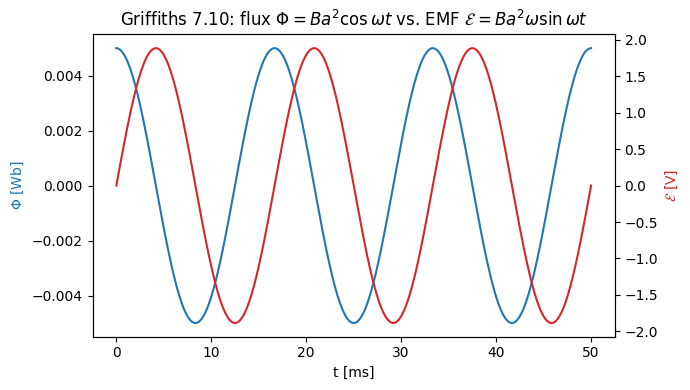

In [4]:
Phi_n = B0_n * a_n**2 * np.cos(omega_n * t_n)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(t_n * 1e3, Phi_n, color="tab:blue", label=r"$\Phi(t)$ [Wb]")
ax1.set_xlabel("t [ms]"); ax1.set_ylabel(r"$\Phi$ [Wb]", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(t_n * 1e3, emf_n, color="tab:red", label=r"$\mathcal{E}(t)$ [V]")
ax2.set_ylabel(r"$\mathcal{E}$ [V]", color="tab:red")
ax1.set_title(r"Griffiths 7.10: flux $\Phi=Ba^2\cos\omega t$ vs. EMF $\mathcal{E}=Ba^2\omega\sin\omega t$")
fig.tight_layout(); plt.show()

## §4 Cross-check: motional EMF on the two moving sides

The flux rule isn't the only way in. The two vertical sides of length $a$ sit at radius $a/2$
from the shaft and move with speed $v=\frac{a}{2}\omega$. Only the velocity component
perpendicular to $\mathbf{B}$ does work on the charges, and that component scales as
$\sin(\omega t)$. Integrating $\oint(\mathbf{v}\times\mathbf{B})\cdot d\boldsymbol{\ell}$ over
both sides gives the *same* $\mathcal{E}=Ba^2\omega\sin\omega t$ — flux rule and motional EMF
are one law (Griffiths 7.13), exactly as in Problem 7.11 (`griffiths.electrodynamics.motional_emf`).

In [5]:
v_n = (a_n / 2) * omega_n
# perpendicular velocity component on each vertical side ~ v*sin(omega t); each side
# contributes B*a*v_perp, and the two sides add (they move oppositely through B)
emf_motional = 2 * B0_n * a_n * v_n * np.sin(omega_n * t_n)
print("max |flux-rule EMF - motional EMF| =", np.max(np.abs(emf_n - emf_motional)))

max |flux-rule EMF - motional EMF| = 2.220446049250313e-16


## Summary

$$\boxed{\mathcal{E}(t) = Ba^2\omega\sin(\omega t)}$$

Same generator law as a transformer/alternator: the EMF amplitude is the product of field,
area, and angular speed, and the two independent derivations (flux rule vs. motional EMF)
agree to numerical precision.